In [3]:
# Importando bibliotecas 
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np 


In [4]:
# Importando dados do Itau
ticker = yf.Ticker('ITUB4.SA')

In [5]:
# Importando Dados de um ano
df_historico = ticker.history(period='1y')

In [6]:
# Mostrando dataset
df_historico

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-08-18 00:00:00-03:00,33.440648,33.849762,33.360606,33.582951,21658634,0.000000,0.0
2025-08-19 00:00:00-03:00,33.145971,33.154954,32.229992,32.607159,40817973,0.352816,0.0
2025-08-20 00:00:00-03:00,32.571246,32.804731,32.373681,32.625126,16894884,0.000000,0.0
2025-08-21 00:00:00-03:00,32.373681,32.714928,32.319798,32.661049,16147619,0.000000,0.0
2025-08-22 00:00:00-03:00,32.777794,33.603973,32.679011,33.577030,32623087,0.000000,0.0
...,...,...,...,...,...,...,...
2026-08-12 00:00:00-03:00,39.209999,39.340000,38.389999,38.430000,49492600,0.000000,0.0
2026-08-13 00:00:00-03:00,38.380001,38.910000,38.160000,38.310001,24129000,0.000000,0.0
2026-08-14 00:00:00-03:00,38.259998,39.130001,37.869999,39.000000,39681400,0.000000,0.0


In [7]:
# Estatisticas descritivas do dataset
df_historico.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02,251.000000,251.000000
mean,39.634850,40.019993,39.227424,39.592644,2.537837e+07,0.013746,0.004104
std,4.038423,4.107859,3.911565,4.009337,1.103835e+07,0.142191,0.065013
min,32.373681,32.714928,32.229992,32.607159,3.225300e+06,0.000000,0.000000
25%,36.032626,36.225959,35.839285,36.086582,1.779455e+07,0.000000,0.000000
50%,39.461956,39.917255,39.083801,39.293701,2.243660e+07,0.000000,0.000000
75%,42.637156,43.012846,42.183807,42.556953,3.261201e+07,0.000000,0.000000
max,48.091133,48.699011,47.649929,48.404877,8.033440e+07,2.172789,1.030000


In [8]:
# Resetando Index
df_historico = df_historico.reset_index()

In [9]:
# Valores numéricos
df_historico[['Close', 'High', 'Open', 'Low', 'Volume']] = df_historico[
    ['Close', 'High', 'Open', 'Low', 'Volume']
].apply(pd.to_numeric)


In [10]:
# Ordenando por data
df_historico = df_historico.sort_values('Date').reset_index(drop=True)

In [11]:
# Informações sobre os dados
df_historico.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                            
---  ------        --------------  -----                            
 0   Date          251 non-null    datetime64[ns, America/Sao_Paulo]
 1   Open          251 non-null    float64                          
 2   High          251 non-null    float64                          
 3   Low           251 non-null    float64                          
 4   Close         251 non-null    float64                          
 5   Volume        251 non-null    int64                            
 6   Dividends     251 non-null    float64                          
 7   Stock Splits  251 non-null    float64                          
dtypes: datetime64[ns, America/Sao_Paulo](1), float64(6), int64(1)
memory usage: 15.8 KB


In [12]:
# Verificando se há valores nulos
df_historico.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

**Média Móveis**: Serve para suavizar o ruído visual(sobe e desce) de um gráfico diário, ajuda a revelar a tendência do ativo em uma janela de tempo, ela é móvel porque avança dia após dia.


In [13]:
# Aplicando Média Móveis 
df_historico['SMA_21'] = df_historico['Close'].rolling(21).mean()
df_historico['SMA_50'] = df_historico['Close'].rolling(50).mean()

**Média Móvel Simples**: Média Aritmética tradicional. boa para identificar níveis de suporte e resistência de longo prazo, é mais estável.


In [14]:
df_historico['SMA_20'] = df_historico['Close'].rolling(20).mean()

**Média Exponencial**: É uma média ponderada, aplica um multiplicador matemático que dá peso maior aos dias mais recentes. O preço de ontem tem muito mais importãncia no calculo do que no preço de 50 dias atrás.

In [15]:
# Aplicando Média Exponencial
df_historico['EMA_21']  = df_historico['Close'].ewm(span=21, adjust=False).mean()
df_historico['EMA_50'] = df_historico['Close'].ewm(span=50, adjust=False).mean()

In [16]:
# Dropando as primeiras linhas (ficam nulos)
df_analise = df_historico.dropna()
df_analise

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_21,SMA_50,SMA_20,EMA_21,EMA_50
49,2025-10-24 00:00:00-03:00,34.497463,34.623303,34.137929,34.182869,10169911,0.0,0.0,34.018394,34.035399,33.982192,34.016731,33.994787
50,2025-10-27 00:00:00-03:00,34.443533,34.704194,34.326681,34.470497,11194349,0.0,0.0,34.005445,34.053150,33.958713,34.057983,34.013442
51,2025-10-28 00:00:00-03:00,34.371624,34.587345,34.326680,34.587345,10478499,0.0,0.0,33.988648,34.092754,33.932991,34.106107,34.035948
52,2025-10-29 00:00:00-03:00,34.650272,35.513156,34.650272,35.360355,27235466,0.0,0.0,34.000960,34.147459,33.977484,34.220129,34.087885
53,2025-10-30 00:00:00-03:00,35.297427,35.665949,35.072718,35.315403,18657008,0.0,0.0,34.041194,34.200546,34.038605,34.319699,34.136023
...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,2026-08-12 00:00:00-03:00,39.209999,39.340000,38.389999,38.430000,49492600,0.0,0.0,41.946932,41.479121,41.888193,41.483942,41.648779
247,2026-08-13 00:00:00-03:00,38.380001,38.910000,38.160000,38.310001,24129000,0.0,0.0,41.717803,41.478498,41.677094,41.195402,41.517846
248,2026-08-14 00:00:00-03:00,38.259998,39.130001,37.869999,39.000000,39681400,0.0,0.0,41.549614,41.489497,41.529984,40.995820,41.419107
249,2026-08-17 00:00:00-03:00,38.919998,38.980000,38.169998,38.380001,21823400,0.0,0.0,41.379985,41.494235,41.334881,40.758019,41.299927


**Golden Cross**: A média móvel de curto prazo acima da de longo prazo, sinalizando tendência de alta.

**Death Cross**: A média Móvel de curto prazo abaixo da de longo prazo, sinalizando tendência de baixa.

In [17]:
# Identificando Golden Cross e Death Cross

df_historico['Sinal'] = np.where(df_historico['SMA_21'] > df_historico['SMA_50'], 1.0, 0.0)

# Diferença entre linhas 
df_historico['Posicao'] = df_historico['Sinal'].diff()

# Dias exatos ondem ocorrem cruzamentos 
cruzamentos  = df_historico[df_historico['Posicao'] != 0.0].dropna()
print(cruzamentos[['Date', 'Close', 'Posicao']])


                         Date      Close  Posicao
57  2025-11-05 00:00:00-03:00  36.086582      1.0
148 2026-03-23 00:00:00-03:00  42.306652     -1.0
172 2026-04-28 00:00:00-03:00  43.630287      1.0
184 2026-05-15 00:00:00-03:00  39.293701     -1.0
218 2026-07-03 00:00:00-03:00  42.721886      1.0
249 2026-08-17 00:00:00-03:00  38.380001     -1.0


In [18]:
fig = go.Figure()

# Linha do Preço de Fechamento Original
fig.add_trace(go.Scatter(x=df_historico['Date'], y=df_historico['Close'],
                         mode='lines', name='Preço de Fechamento', opacity=0.5))

# Linha da SMA 21
fig.add_trace(go.Scatter(x=df_historico['Date'], y=df_historico['SMA_21'],
                         mode='lines', name='SMA 21 Dias', line=dict(color='orange', width=2)))

# Linha da SMA 50
fig.add_trace(go.Scatter(x=df_historico['Date'], y=df_historico['SMA_50'],
                         mode='lines', name='SMA 50 Dias', line=dict(color='red', width=2)))

# Marcadores  Golden Cross
golden_cross = df_historico[df_historico['Posicao'] == 1.0]
fig.add_trace(go.Scatter(x=golden_cross['Date'], y=golden_cross['SMA_50'],
                         mode='markers', name='Golden Cross (Alta)',
                         marker=dict(symbol='triangle-up', color='green', size=12)))

# Marcadores para o Death Cross
death_cross = df_historico[df_historico['Posicao'] == -1.0]
fig.add_trace(go.Scatter(x=death_cross['Date'], y=death_cross['SMA_50'],
                         mode='markers', name='Death Cross (Baixa)',
                         marker=dict(symbol='triangle-down', color='white', size=12)))

# Layout dos Gráficos 
fig.update_layout(title='Análise de Tendências e Cruzamentos de Média Móveis - Itaú',
                  xaxis_title='Período Analisado',
                  yaxis_title='Preço',
                  template='plotly_dark')
fig.update_xaxes(
    dtick='M1',
    tickformat='%m/%Y',
    ticklabelmode='period'
)


fig.show()


Das 4 **Golden Cross**, apenas 11/2025 gerou tendência de alta clara e duradoura, cruzamentos de média curtas (21/50) geram bastante ruídos nesse ativo, média mais longas tendem a ser mais confiáveis.

In [19]:
# Variação Diária do Preço Ativo Itaú

fig = go.Figure(data=[go.Candlestick(x=df_historico['Date'],
                                     open=df_historico['Open'],
                                     high=df_historico['High'],
                                     low=df_historico['Low'],
                                     close=df_historico['Close'])])

fig.update_layout(title='<b>Variação Diária do Preço do Itaú<b>',
                  title_x=0.5,
                  yaxis_title='Preço',
                  xaxis_rangeslider_visible=False)

fig.update_xaxes(
    dtick='M1',
    tickformat='%m/%Y',
    ticklabelmode='period'
)

fig.show()

Do início ao fechamento o retorno bruto foi de +14% no ano.  
O Ativo chegou a **valorizar** 47% da mínima(33.92) até a máxima (47.64), e depois devolvendo boa parte do ganho, fechando o ano abaixo do topo.

**Análise de Volatilidade**: Construindo Bnadas de Bollinger a partir do desvio padrão dos preços, identificando os períodos de maior turbulência.


In [20]:
# Multiplicador padrão do Mercado Financeiro
k = 2

# Calculando Desvio Padrão

df_historico['STD_20'] = df_historico['Close'].rolling(20).std()

#Bandas para janelas de 20 períodos
df_historico['Upper_Band_20'] = df_historico['SMA_20'] + (df_historico['STD_20'] * k)
df_historico['Lower_Band_20'] = df_historico['SMA_20'] - (df_historico['STD_20'] * k)

In [21]:
fig = go.Figure()
fig.add_trace(go.Candlestick(
    x=df_historico['Date'],
    open=df_historico['Open'],
    high=df_historico['High'],
    low=df_historico['Low'],
    close=df_historico['Close'],
    name='Preço'

))

fig.add_trace(go.Scatter(
    x=df_historico['Date'],
    y=df_historico['Upper_Band_20'],
    mode='lines',
    line=dict(color='rgba(150, 150, 150, 0.6)', width=1.5, dash='dot'),
    name='Banda Superior (20)'
))

fig.add_trace(go.Scatter(
    x=df_historico['Date'],
    y=df_historico['Lower_Band_20'],
    mode='lines',
    line=dict(color='rgba(150, 150, 150, 0.6)', width=1.5, dash='dot'),
    name='Banda Inferior (20)'
))

fig.add_trace(go.Scatter(
    x=df_historico['Date'],
    y=df_historico['SMA_20'],
    mode='lines',
    line=dict(color='gray', width=1),
    name='SMA 20'
))

fig.update_layout(
    title='Análise de Volatilidade: Preço vs Bandas de Bollinger (20 Perídos)',
    yaxis_title='Preço do Ativo',
    xaxis_title='Período Analisado',
    xaxis_rangeslider_visible=False, # Removendo o slider inferior duplo
    template='plotly_dark', # O tema escuro ajuda a destacar o preenchimento

    )
fig.update_xaxes(
    dtick='M1',
    tickformat='%m/%Y'
)


fig.show()



A largura das banda mais que dobrou ante o começo e o fim do período- evidência objetiva que a volatilidade do papel aumentou ao longo do ano, e não ficou estável.

Movimentos bruscos visto no gráfico(alta e seguida de forte correção) e com retorno mensais extremos em janeiro.

In [22]:
# Calcular o retorno Diário
df_historico['Retorno_Diario'] = df_historico['Close'].pct_change()

# Calcular Retorno Acumulado
df_historico['Retorno_Acumulado'] = (1 + df_historico['Retorno_Diario']).cumprod()

# Aporte Inicial

aporte_inicial_2 = 4000

In [23]:
# Calculando dois valores 

df_historico['Capital_Acumulado'] = aporte_inicial_2 * df_historico['Retorno_Acumulado']

In [24]:
# Primeira linha possui valor nulo, substituindo com o aporte inicial

df_historico.loc[0, 'Capital_Acumulado'] = aporte_inicial_2

In [25]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_historico['Date'],
    y=df_historico['Capital_Acumulado'],
    mode='lines',
    name='Capital Acumulado',
    line=dict(color='#00cc96', width=2), # Verde mercado financeiro
    fill='tozeroy',
    fillcolor='rgba(0, 204, 150, 0.1)'
))

fig.add_trace(go.Scatter(
    x=[df_historico['Date'].iloc[0], df_historico['Date'].iloc[-1]],
    y=[aporte_inicial_2, aporte_inicial_2],
    mode='lines',
    name='Aporte Inicial 4000R$',
    line=dict(color='gray', width=1.5, dash='dash')
))

fig.update_layout(
    title='Evolução do Capital: R$4000 Investidos em Agosto de 2025',
    yaxis_title='Capital Acumulado',
    xaxis_title='Data',
    template='plotly_dark'
)

fig.update_xaxes(
    dtick='M1',
    tickformat='%m/%Y'
)
fig.show()

In [26]:
df_historico['Capital_Acumulado'].max()

np.float64(5765.410823723876)

**Capital Inicial**: R$4.000
Quem investisse R$4.000 em Agosto de 2025 e vendesse no pico(por volta de jan/2026) teria quase 45% de ganho.  

**Pico** de R$5.786.87(44,7%)  

**Valor final**: 4.549,39(13,7%)

In [27]:
# Importando API do Banco Central 
from bcb import sgs

# Puxando dados 
cdi_data = sgs.get({'CDI': 12}, start='2025-08-01')

# Mostrando a base de dados exportada
cdi_data


,CDI
Date,
2025-08-01,0.055131
2025-08-04,0.055131
2025-08-05,0.055131
2025-08-06,0.055131
2025-08-07,0.055131
...,...
2026-08-11,0.051660
2026-08-12,0.051660
2026-08-13,0.051660


In [28]:
# Resetando Index
cdi_data = cdi_data.reset_index()

# Ordenando por data
cdi_data = cdi_data.sort_values('Date').reset_index(drop=True)


In [29]:
# Informações 
cdi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    263 non-null    datetime64[ns]
 1   CDI     263 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.2 KB


In [30]:
# Verificando Valores Nulos
cdi_data.isnull().sum()

Date    0
CDI     0
dtype: int64

In [31]:
# Estatisticas
cdi_data.describe()

,Date,CDI
count,263,263.000000
mean,2026-02-06 19:20:45.627376384,0.054370
min,2025-08-01 00:00:00,0.051660
25%,2025-11-01 12:00:00,0.053400
50%,2026-02-05 00:00:00,0.055131
75%,2026-05-14 12:00:00,0.055131
max,2026-08-17 00:00:00,0.055131
std,NaN,0.001071


In [32]:
# Calculando Retorno Diário  
cdi_data['Retorno_Diario_CDI'] = cdi_data['CDI'] / 100

# Calculando Retorno Acumulado 
cdi_data['Retorno_Acumulado_CDI'] = (1 + cdi_data['Retorno_Diario_CDI']).cumprod()
cdi_data['Retorno_Acumulado_CDI.Pct'] = (cdi_data['Retorno_Acumulado_CDI'] - 1) * 100

# Calculando Capital Acumulado com aporte de 4000
aporte_inicial_cdi = 4000
cdi_data['Capital_Acumulado_CDI'] = aporte_inicial_cdi * cdi_data['Retorno_Acumulado_CDI']



In [33]:
cdi_data

,Date,CDI,Retorno_Diario_CDI,Retorno_Acumulado_CDI,Retorno_Acumulado_CDI.Pct,Capital_Acumulado_CDI
0,2025-08-01,0.055131,0.000551,1.000551,0.055131,4002.205240
1,2025-08-04,0.055131,0.000551,1.001103,0.110292,4004.411696
2,2025-08-05,0.055131,0.000551,1.001655,0.165484,4006.619368
3,2025-08-06,0.055131,0.000551,1.002207,0.220706,4008.828257
4,2025-08-07,0.055131,0.000551,1.002760,0.275959,4011.038364
...,...,...,...,...,...,...
258,2026-08-11,0.051660,0.000517,1.151296,15.129648,4605.185913
259,2026-08-12,0.051660,0.000517,1.151891,15.189124,4607.564952
260,2026-08-13,0.051660,0.000517,1.152486,15.248631,4609.945220
261,2026-08-14,0.051660,0.000517,1.153082,15.308168,4612.326718


In [34]:
# Mudando o Fuso-Horário da Coluna 'Date' para fazer o merge 
cdi_data['Date'] = cdi_data['Date'].dt.tz_localize('America/Sao_Paulo')

In [35]:
df_comparativo = pd.merge(df_historico, cdi_data, on='Date', how='left')

In [36]:
# Visualizando o merge
df_comparativo

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_21,SMA_50,...,Upper_Band_20,Lower_Band_20,Retorno_Diario,Retorno_Acumulado,Capital_Acumulado,CDI,Retorno_Diario_CDI,Retorno_Acumulado_CDI,Retorno_Acumulado_CDI.Pct,Capital_Acumulado_CDI
0,2025-08-18 00:00:00-03:00,33.440648,33.849762,33.360606,33.582951,21658634,0.000000,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,4000.000000,0.055131,0.000551,1.006636,0.663582,4026.543269
1,2025-08-19 00:00:00-03:00,33.145971,33.154954,32.229992,32.607159,40817973,0.352816,0.0,NaN,NaN,...,NaN,NaN,-0.029056,0.970944,3883.775319,0.055131,0.000551,1.007191,0.719079,4028.763142
2,2025-08-20 00:00:00-03:00,32.571246,32.804731,32.373681,32.625126,16894884,0.000000,0.0,NaN,NaN,...,NaN,NaN,0.000551,0.971479,3885.915360,0.055131,0.000551,1.007746,0.774606,4030.984239
3,2025-08-21 00:00:00-03:00,32.373681,32.714928,32.319798,32.661049,16147619,0.000000,0.0,NaN,NaN,...,NaN,NaN,0.001101,0.972549,3890.194079,0.055131,0.000551,1.008302,0.830164,4033.206561
4,2025-08-22 00:00:00-03:00,32.777794,33.603973,32.679011,33.577030,32623087,0.000000,0.0,NaN,NaN,...,NaN,NaN,0.028045,0.999824,3999.294831,0.055131,0.000551,1.008858,0.885753,4035.430109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,2026-08-12 00:00:00-03:00,39.209999,39.340000,38.389999,38.430000,49492600,0.000000,0.0,41.946932,41.479121,...,44.454881,39.321504,-0.014615,1.144331,4577.322674,0.051660,0.000517,1.151891,15.189124,4607.564952
247,2026-08-13 00:00:00-03:00,38.380001,38.910000,38.160000,38.310001,24129000,0.000000,0.0,41.717803,41.478498,...,44.678506,38.675683,-0.003123,1.140757,4563.029835,0.051660,0.000517,1.152486,15.248631,4609.945220
248,2026-08-14 00:00:00-03:00,38.259998,39.130001,37.869999,39.000000,39681400,0.000000,0.0,41.549614,41.489497,...,44.756647,38.303320,0.018011,1.161304,4645.214231,0.051660,0.000517,1.153082,15.308168,4612.326718
249,2026-08-17 00:00:00-03:00,38.919998,38.980000,38.169998,38.380001,21823400,0.000000,0.0,41.379985,41.494235,...,44.830725,37.839036,-0.015897,1.142842,4571.367362,0.051660,0.000517,1.153677,15.367736,4614.709446


In [37]:

# Removendo Valores Nulos
df_comparativo = df_comparativo.ffill()
df_comparativo = df_comparativo.dropna()

In [38]:
# Verificando Valores Nulos
df_comparativo.isnull().sum()

Date                         0
Open                         0
High                         0
Low                          0
Close                        0
Volume                       0
Dividends                    0
Stock Splits                 0
SMA_21                       0
SMA_50                       0
SMA_20                       0
EMA_21                       0
EMA_50                       0
Sinal                        0
Posicao                      0
STD_20                       0
Upper_Band_20                0
Lower_Band_20                0
Retorno_Diario               0
Retorno_Acumulado            0
Capital_Acumulado            0
CDI                          0
Retorno_Diario_CDI           0
Retorno_Acumulado_CDI        0
Retorno_Acumulado_CDI.Pct    0
Capital_Acumulado_CDI        0
dtype: int64

In [39]:
# Aplicando Normalização de Base 100 para comparação igualitária
df_comparativo['Itau_Norm'] = (df_comparativo['Close'] / df_comparativo['Close'].iloc[0]) * 100
df_comparativo['CDI_Norm'] = (df_comparativo['Capital_Acumulado_CDI'] / df_comparativo['Capital_Acumulado_CDI'].iloc[0]) * 100

In [40]:

# Gráfico

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_comparativo['Date'],
    y=df_comparativo['Itau_Norm'],
    mode='lines',
    name='Itaú',
    line=dict(color='#FFA500', width=2)

))

fig.add_trace(go.Scatter(
    x=df_comparativo['Date'],
    y=df_comparativo['CDI_Norm'],
    mode='lines',
    name='CDI',
    line=dict(color='#00FF00', width=2)
))

fig.update_layout(
    title='Comparativo de Desempenho (Base 100): Itaú VS CDI ',
    yaxis_title='Crescimento Acumulado (Base 100)',
    xaxis_title='Período Analisado',
    template='plotly_dark',
    width=900, height=500 
)

fig.update_yaxes(type='linear')
fig.update_xaxes(dtick='M1' , tickformat='%m/%Y')
fig.show()

Ambos partem do 113,09 **Itáu** termina em 111,09 e o **CDI** termina em 111,55. **Itaú** chegou a 141.60.  
**Conculusão Final**: Itáu rendeu menos que o **CDI**.

**CDI**: Renda Fixa  

**ITÁU**: Renda Variável

**Análise Fundamentalista**

**ROE**: Rentabilidade do Banco.
**P/L (Preço sobre Lucro) e P/VP (Preço sobre Valor Patrimonial)**: indicam se a ação está barata ou cara em relação ao lucro gerado e ao seu patrimônio líquido.  

**Dividend Yield e JCP**: avaliam o retorno em dinheiro pago aos acionistas por meio de dividendos e Juros sobre Capital Próprio.  

**Índice de Inadimplência (NPL) e Cobertura**: mostram a qualidade da carteira de crédito e o risco de calote dos clientes.

In [41]:
# Obtendo Lucro Líquido Via API
DRE = ticker.income_stmt
lucro_liquido = DRE.loc['Net Income'].iloc[0]

# Patrimônio Líquido mais recente
balanco = ticker.balance_sheet
patrimonio_liquido = balanco.loc['Stockholders Equity'].iloc[0]


In [42]:
# Calcular Roe 
roe = (lucro_liquido / patrimonio_liquido) * 100

In [43]:
print(f'lucro_liquido: {lucro_liquido:,.2f}')
print(f'Patrimônio Líquido: {patrimonio_liquido:,.2f}')
print(f'ROE: {roe:.2f}')

lucro_liquido: 44,857,000,000.00
Patrimônio Líquido: 204,501,000,000.00
ROE: 21.93


In [44]:
data_bruta = DRE.columns[0]
data_formatada = pd.to_datetime(data_bruta).strftime('%d/%m/%Y')

In [45]:
# Tranformando para Bilhões
lucro_bi = lucro_liquido / 1e9
patrimonio_bi = patrimonio_liquido / 1e9

In [46]:
# Três Metricas
barras = pd.DataFrame({
    'Métrica': ['Lucro Líquido (bi)', 'Patrimônio Líquido (bi)', 'ROE (%)'],
    'Valor': [lucro_bi, patrimonio_bi, roe]
})

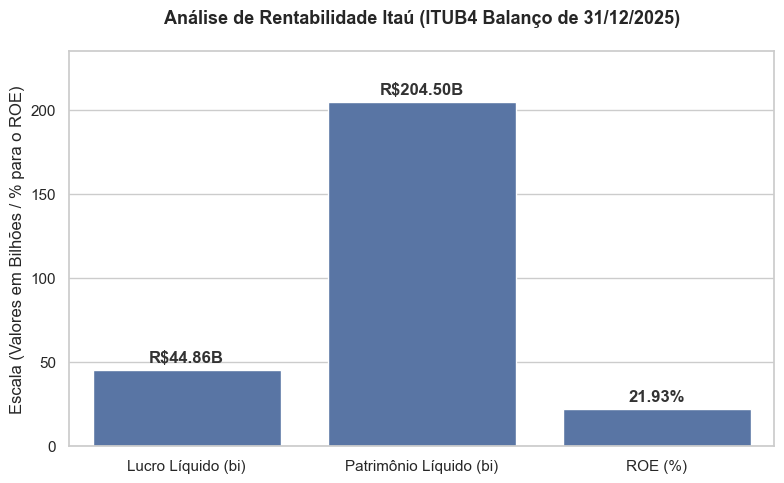

In [47]:
plt.figure(figsize=(8, 5))
sns.set_theme(style='whitegrid')
grafico = sns.barplot(data=barras , x='Métrica', y='Valor')

# Adicionando valores nas barras
for p in grafico.patches:
    valor_barra = p.get_height()
    sufixo = "%" if valor_barra == roe else "B"
    prefixo  = "" if valor_barra == roe else "R$"

    grafico.annotate(f'{prefixo}{valor_barra:.2f}{sufixo}',
                     (p.get_x() + p.get_width() / 2., valor_barra),
                     ha='center', va='center',
                     xytext=(0,9),
                     textcoords='offset points',
                     fontweight='bold', color='#333333')
plt.title(f'Análise de Rentabilidade Itaú (ITUB4 Balanço de {data_formatada})', fontsize=13, fontweight='bold', pad=20)
plt.ylabel('Escala (Valores em Bilhões / % para o ROE)')
plt.xlabel('')
plt.ylim(0, max(lucro_bi, patrimonio_bi, roe) * 1.15)
plt.tight_layout()
plt.show()


Um **ROE** de 21.93% é forte e bate com a realidade do setor bancário.

**Lucro Líquido** Maior lucro registrado do banco e o maior resultado registrado por uma banco brasileiro.

In [48]:
# Preco e Total de Ações
preco_atual = ticker.info.get('currentPrice')
total_acoes = ticker.info.get('sharesOutstanding')

In [49]:
if total_acoes is None:
    df_acoes = ticker.get_shares_full()
    if df_acoes is not None and not df_acoes.empty:
        total_acoes = df_acoes.iloc[-1]

In [50]:
if total_acoes and preco_atual:
    # Lucro por ação 
    LPA = lucro_liquido / total_acoes
# Valor por ação
    VPA = patrimonio_liquido / total_acoes


In [51]:
pl = preco_atual / LPA
pvp = preco_atual / VPA

In [52]:
# Duas Metricas
barras_2 = pd.DataFrame({
    'Métrica': ['Preço/Lucro', 'Preço/Valor Patrimônial'],
    'Valor': [pl, pvp]
})

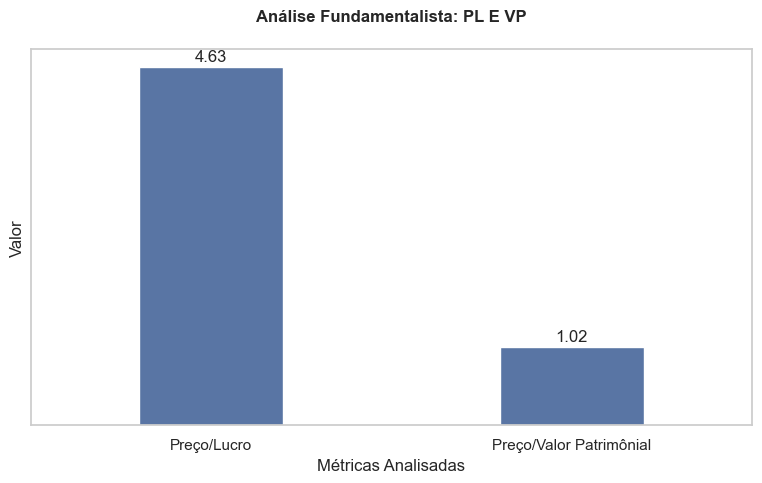

In [53]:
plt.figure(figsize=(8, 5))
sns.set_theme(style='whitegrid')
grafico = sns.barplot(data=barras_2 , x='Métrica', y='Valor', width=0.4)
grafico.bar_label(grafico.containers[0], fmt='%.2f', padding=2)
plt.title('Análise Fundamentalista: PL E VP', fontweight='bold', pad=20)
plt.xlabel('Métricas Analisadas')
plt.tight_layout()
plt.yticks([])
plt.show()

**P/L**: O mercado paga o equivalente a 9,3 anos de lucro pela ação, nem "caro" e nem "barato".  
**P/VP**: Banco com **ROE de 21.93%** tendem a negociar com ágio sobre o valor patromonial.

**Conclusão Final**: Não indicam nem  subvalorização e nem sobrevalorização, estão alinhados com a rentabilidade apresentada.

In [54]:
# Historico de Preços e Dividendos  em 5 anos
historico_precos = ticker.history(period='5y')
historico_dividendos = ticker.dividends

In [55]:
# Indíces sem fuso horário 
historico_precos.index = pd.to_datetime(historico_precos.index).tz_localize(None)
historico_dividendos.index = pd.to_datetime(historico_dividendos.index).tz_localize(None)


In [56]:
# Agrupamos e somamos o dividendos por ano
div_anuais = historico_dividendos.groupby(historico_dividendos.index.year).sum()
div_anuais = div_anuais.loc[2021:2025]

In [57]:
# Preco de fechamendo no ultimo dia de cada ano
precos_anuais = historico_precos['Close'].groupby(historico_precos.index.year).last()
precos_anuais = precos_anuais.loc[2021:2025]


In [58]:
# Dividend Yield Historico por ano (%)
dy_historico = (div_anuais / precos_anuais) * 100

In [59]:
# Tranformando Series em DataFrame e resetando o índice
dy_df = dy_historico.to_frame().reset_index()
# Remomeando as colunas 
dy_df.columns = ['Ano', 'Dividend_Yield']



In [60]:

# Gráfico
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=dy_df['Ano'],
    y=dy_df['Dividend_Yield'],
    mode='lines+markers+text',
    text=dy_df['Dividend_Yield'].round(2),
    textposition='top center',
    name='Itaú',
    line=dict(color='#26A69A', width=2)
    

))

fig.update_layout(
    title='Evolução do Dividend Yield do Itaú ao longo dos Anos',
    yaxis_title='DY',
    xaxis_title='Período Analisado',
    template='plotly_dark',
    width=1000, height=500
)

fig.update_xaxes(tickformat='%Y')
fig.show()


Entre 2021 e 2023 houve uma queda significativa, e a partir de 2024 há um salto expressivo e em 2025 também, dobrando em dois anos.

In [61]:
# Criando uma função para extrair dados Inadimplência
def extrair_serie_bacen(codigo_serie, nome_coluna):
    url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo_serie}/dados?formato=json"
    df = pd.read_json(url)
    df["data"] = pd.to_datetime(df["data"], dayfirst=True)
    df[nome_coluna] = pd.to_numeric(df["valor"])
    return df[["data", nome_coluna]].set_index("data")


# 2. CHAMADA DA FUNÇÃO (encostado na margem esquerda, sem recuo)
df_inadimplencia = extrair_serie_bacen(21083, "Inadimplencia_PF")
df_inadimplencia.head()

,Inadimplencia_PF
data,
2011-03-01,1.96
2011-04-01,2.04
2011-05-01,2.15
2011-06-01,2.09
2011-07-01,2.18


In [62]:
# Puxando os Dados 
series_alvo = {
    21083: "Inadimplencia_PF",
    21084: "Inadimplencia_PJ", 
    20717: "Taxa_Juros_PF",  
    19882: "Comprometimento_Renda",  
}

In [63]:
# Puxando todos os dados de uma vez
lista_data = []
for codigo, nome_coluna in series_alvo.items():
    df = extrair_serie_bacen(codigo, nome_coluna)
    lista_data.append(df)
df_itau_inadimplencia = pd.concat(lista_data, axis=1)

In [64]:
# Removendo valores Nulos 
df_itau_inadimplencia.dropna(inplace=True)
# Visualizando Dados
df_itau_inadimplencia
# Resetando Index para coluna
df_itau_inadimplencia.reset_index('data', inplace=True)

In [65]:
df_itau_inadimplencia = df_itau_inadimplencia.rename(columns={'data': 'Date'})


In [66]:
df_historico_2 = yf.download("ITUB4.SA", start="2011-01-01", end="2021-12-31")

# Pegando apenas o preço de fechamento e transformando em mensal
df_itau_historico = df_historico_2[['Close']].resample('ME').last()
# Resetando Index
df_historico_2.reset_index()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA
0,2011-01-03,7.165775,7.238011,7.124240,7.151328,11346613
1,2011-01-04,7.223562,7.265098,7.151326,7.169385,14372311
2,2011-01-05,7.331913,7.340943,7.140489,7.187442,13758960
3,2011-01-06,7.158549,7.312050,7.151326,7.297603,19336594
4,2011-01-07,6.983377,7.198277,6.945453,7.144100,17289272
...,...,...,...,...,...,...
2723,2021-12-23,13.902160,14.051996,13.791412,13.895644,25353141
2724,2021-12-27,14.045485,14.136689,13.882621,13.993368,15891231
2725,2021-12-28,13.993367,14.136688,13.941251,14.091086,17328328


In [67]:

# Fechamento Mensal 
fechamento_mensal = df_historico_2[['Close']].resample('ME').last()
# Retorno Mensal
retorno_mensal = fechamento_mensal
retorno_mensal



Price,Close
Ticker,ITUB4.SA
Date,
2011-01-31,6.427161
2011-02-28,6.684051
2011-03-31,7.102418
2011-04-30,6.775862
2011-05-31,6.547858
...,...
2021-08-31,19.866129
2021-09-30,18.584541


In [68]:
df_retorno_mensal = retorno_mensal.reset_index()

In [69]:
df_retorno_mensal['Date'] = df_retorno_mensal['Date'].dt.tz_localize(None)

In [70]:
df_retorno_mensal

Price,Date,Close
Ticker,,ITUB4.SA
0,2011-01-31,6.427161
1,2011-02-28,6.684051
2,2011-03-31,7.102418
3,2011-04-30,6.775862
4,2011-05-31,6.547858
...,...,...
127,2021-08-31,19.866129
128,2021-09-30,18.584541
129,2021-10-31,14.982046


In [71]:
df_retorno_mensal

Price,Date,Close
Ticker,,ITUB4.SA
0,2011-01-31,6.427161
1,2011-02-28,6.684051
2,2011-03-31,7.102418
3,2011-04-30,6.775862
4,2011-05-31,6.547858
...,...,...
127,2021-08-31,19.866129
128,2021-09-30,18.584541
129,2021-10-31,14.982046


In [72]:
# Comprimindo a coluna
df_retorno_mensal.columns = df_retorno_mensal.columns.get_level_values(0)

# Tranformando em Datetime
df_itau_inadimplencia['Date'] = pd.to_datetime(df_itau_inadimplencia['Date'])
df_retorno_mensal['Date'] = pd.to_datetime(df_retorno_mensal['Date'])

df_itau_inadimplencia['Mes_Ano'] = df_itau_inadimplencia['Date'].dt.to_period('M')
df_retorno_mensal['Mes_Ano'] = df_retorno_mensal['Date'].dt.to_period('M')

df_merge_itau = pd.merge(df_itau_inadimplencia, df_retorno_mensal, on='Mes_Ano', how='left')
df_merge_itau = df_merge_itau.drop(columns=['Date_x', 'Date_y'], errors='ignore')

display(df_merge_itau)

,Inadimplencia_PF,Inadimplencia_PJ,Taxa_Juros_PF,Comprometimento_Renda,Mes_Ano,Close
0,1.96,4.62,37.92,41.90,2011-03,7.102418
1,2.04,4.67,38.71,41.99,2011-04,6.775862
2,2.15,4.82,38.40,42.28,2011-05,6.547858
3,2.09,4.79,38.28,42.59,2011-06,6.661531
4,2.18,4.90,38.67,42.74,2011-07,5.758773
...,...,...,...,...,...,...
121,1.33,2.95,28.66,58.27,2021-04,17.551680
122,1.57,3.01,27.99,59.26,2021-05,18.874775
123,1.54,2.91,27.93,59.55,2021-06,19.050571
124,1.58,2.94,28.37,59.17,2021-07,19.379963


In [73]:
df_precos = df_merge_itau[[ 'Inadimplencia_PF',	'Inadimplencia_PJ',	'Taxa_Juros_PF', 'Comprometimento_Renda', 'Close']]
df_preco_mensal = df_precos.dropna(subset=['Inadimplencia_PF', 'Taxa_Juros_PF'])
df_retornos_precos = df_preco_mensal.dropna()
matriz_correlacao = df_retornos_precos.corr()



Text(0.5, 1.0, 'Matriz de Correlação: Preço de Fechamento Mensal e Quatro Variáveis de Inadimplência')

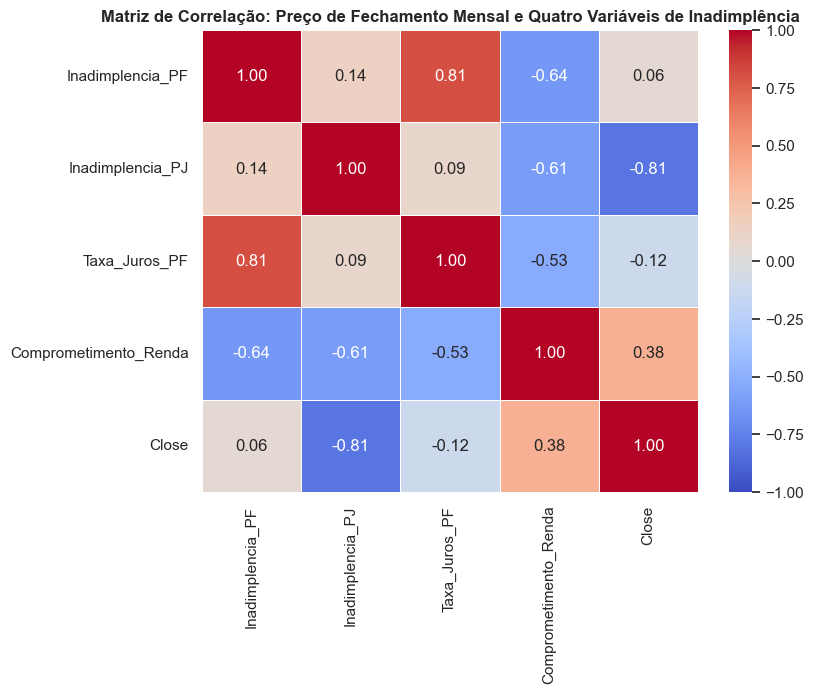

In [74]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_correlacao,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.5,
    fmt='.2f'
)
plt.title('Matriz de Correlação: Preço de Fechamento Mensal e Quatro Variáveis de Inadimplência', fontweight='bold')

In [75]:
# Vou tranformando a Coluna 'Mes_Ano' em String
df_merge_itau['Mes_Ano'] = df_merge_itau['Mes_Ano'].astype(str)

In [76]:
# Criando Figura com Eixo secundario
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add traces
fig.add_trace(
    go.Scatter(x=df_merge_itau['Mes_Ano'], y=df_merge_itau['Close'], name='Preço Fechamento Mensal'),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=df_merge_itau['Mes_Ano'], y=df_merge_itau['Taxa_Juros_PF'], 
               name='Taxa de Juros PF'),
            secondary_y=True,
 
)
fig.update_layout(
    title='Análise de Tendências: Preço fechemento mensal X Taxa de Juros PF ',
    yaxis_title='Preço de Fechamento',
    xaxis_title='Período Analisado',
    template='plotly_dark'
)
fig.update_xaxes(tickformat='%Y')


fig.show()

In [81]:
df_comparativo.to_csv('base_itau_comparativa', index=False, encoding='utf-8-sig')